In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
#psf_name = 'king'
psf_name = 'delta'
if psf_name == 'king':
    kp = KingPSF()
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)
elif psf_name == 'delta':
    sigma = np.deg2rad(0.1) / 3
    psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=30)

df = f_ary[1] - f_ary[0]
plot = False
if plot:
    plt.plot(f_ary, df_rho_div_f_ary/df*f_ary**2)
    plt.fill_between(f_ary, df_rho_div_f_ary/df*f_ary**2, 0., alpha=0.5)
    plt.ylabel(r'$f\cdot\rho(f)$')
    plt.xlabel(r'$f$');

## scan ll

In [3]:
run_name = 'sim_t0'
vd = pickle.load(open(f'{run_name}/truth.p', 'rb'))

temps = {f't{i}' : np.load(f'temp_{i}.npy') for i in range(5)}
for k in temps.keys():
    temps[k] /= np.mean(temps[k])

# S over A
Sps_over_A_dict = {}
for k in ['t0', 't1']:
    s_ary = np.logspace(-1., 2., 100)
    theta_tmp = np.array([1., vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]])
    dnds_ary = dnds(s_ary, theta_tmp)
    Sps_over_A_dict[k] = np.mean(temps[k]) * np.trapz(s_ary * dnds_ary, s_ary)

In [7]:
ll_func = log_like
#ll_func = npll.log_like
Sps_key = 't0'
vk = vd['Sps_'+Sps_key]
Sps_s = np.linspace(0.5*vk, 1.5*vk, 50)
save_fn = f'{run_name}/ll_ss.p'
include_ps_k = ['t0']

ll_ss = []
counts_arr = []
pt_sum_compressed = np.full_like(temps['t0'], 1e-10, dtype=np.float64)
npt_compressed = [np.array(temps[k], dtype=np.float64) for k in include_ps_k]

for i_data in tqdm(range(50)):
    ll_s = []
    fermi_data = np.load(f'{run_name}/counts_{i_data}.npy').astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps in enumerate(Sps_s):
        A = {}
        for k in include_ps_k:
            A[k] = vd['Sps_'+k] / Sps_over_A_dict[k]
        A[Sps_key] = Sps / Sps_over_A_dict[k]
        theta = np.array([ [A[k], vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['sb1_'+k]*vd['lambdas_'+k]] for k in include_ps_k ], dtype=np.float64)
        ll = ll_func(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)
pickle.dump(ll_ss, open(save_fn, 'wb'))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [03:41<00:00,  4.44s/it]


In [26]:
ll_ss = pickle.load(open(save_fn, 'rb'))

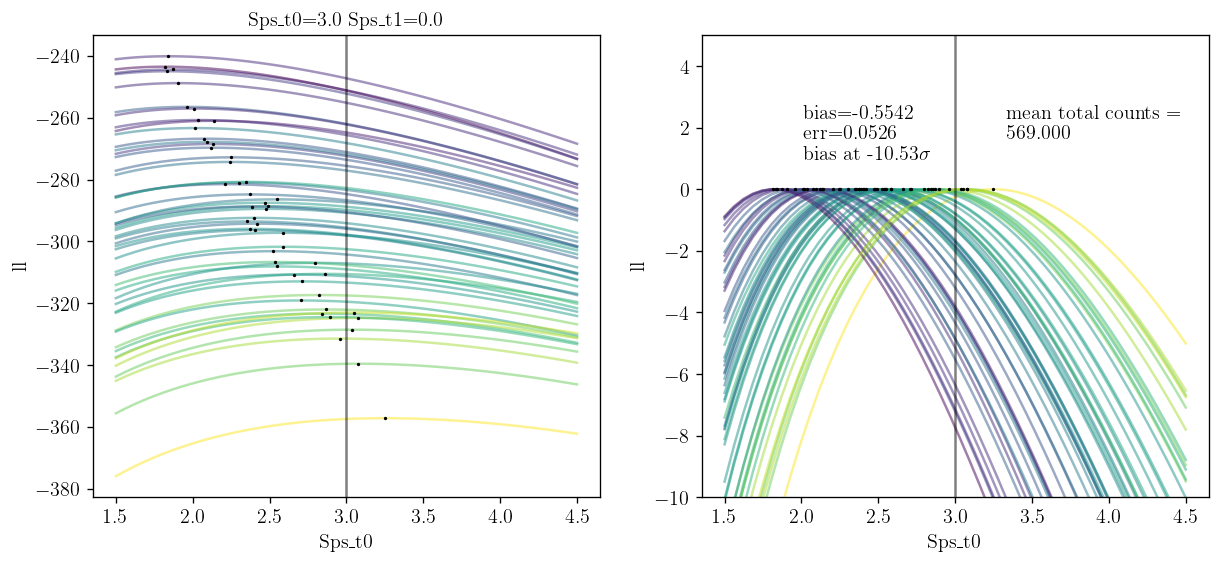

In [12]:
ll_ss = np.array(ll_ss).astype(np.float64)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in ['t0', 't1']])

ax = axs[0]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.2, 0.85, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$", transform=ax.transAxes, va='top')
ax.text(0.6, 0.85, f"mean total counts = \n{np.mean(counts_arr):.3f}", transform=ax.transAxes, va='top');

In [4]:
import numpy as np
from mpmath import mp

## Precalculate log(m!) for m in [0, fct_max - 1]
# If data map has more than fct_max counts per pixel fct_max must be increased
fct_max = 30000

def log_factorial(m):
    return np.sum(np.log(np.arange(1., m + 1., dtype=np.float128)))

log_factorial_ary = np.vectorize(log_factorial)(np.arange(fct_max))

def incgamma_up_fct_ary(m_max, z, a):
    """ Upper incomplete gamma function / m!

    Calculation performed using gamma function recursion relation.

    Returns:
        float64 numpy array of Gamma(z+m,a)/m! for m in [0,m_max]

    """

    igf_list = np.zeros(m_max + 1, dtype=np.float128)
    igf_list[0] = np.float128(mp.gammainc(z, a))

    # i_array[m] = m+1
    i_array = np.arange(1., m_max + 1., dtype=np.float128)
    
    for i in np.arange(1,m_max+1):
        igf_list[i] = ((i_array[i-1] - 1. + z)*igf_list[i-1]/i 
                      + np.exp((i_array[i-1] - 1. + z)*np.log(a) - a 
                      - log_factorial_ary[i]))

    return np.asarray(igf_list, dtype=np.float128)

def incgamma_lo_fct_ary(m_max, z, a):
    """ Lower incomplete gamma function / m!

    Calculation performed using gamma function recursion relation.
    Starts at m_max and moves backwards for greater precision.

    Returns:
        float64 numpy array of Gamma(z+m,0,a)/m! for m in [0,m_max]

    """

    igf_list = np.zeros(m_max + 1,dtype=np.float128)
    igf_list[m_max] = np.float128(mp.gammainc(z + m_max, 0, a) / mp.factorial(m_max))
    # NB: use mp.factorial, since np.math.factorial overflows for m ~ 170

    # i_array[m] = m_max-m
    i_array = np.arange(m_max, 0, -1, dtype=np.float128)

    for i in np.arange(m_max, 0, -1):
        igf_list[i-1] = ((igf_list[i] 
                        + np.exp((i_array[-i] - 1. + np.float128(z))
                        *np.log(np.float128(a)) - np.float128(a) 
                        - log_factorial_ary[i]))*i_array[-i]
                        /(i_array[-i] - 1. + np.float128(z)))

    return np.asarray(igf_list, dtype=np.float128)


In [5]:
def return_xs(theta, f_ary, df_rho_div_f_ary, npt_compressed, data):

    a_ps, n1, n2, n3, sb1, sb2 = theta

    k_max = int(np.max(data) + 1)
    npix_roi = len(npt_compressed)

    x_m_ary = np.zeros(shape=(npix_roi,k_max + 1))
    x_m_sum = np.zeros(npix_roi)

    g0_ary_f = np.zeros(k_max + 1)
    g1_ary_f = np.zeros(k_max + 1)
    g2_ary_f = np.zeros(k_max + 1)

    f2, df_rho_div_f2 = 0., 0.
    pref0_x_m_ary, pref1_x_m_ary, pref2_x_m_ary = 0., 0., 0.
    first0_x_m_sum_ary, first1_x_m_sum_ary, first2_x_m_sum_ary = 0., 0., 0.
    second0_x_m_sum_ary, second1_x_m_sum_ary, second2_x_m_sum_ary = 0., 0., 0.
    x_m_sum_f, x_m_ary_f = 0., 0.

    #cdef Py_ssize_t f_index, p, k

    first0_x_m_sum_ary = 1/(1-n1)
    first1_x_m_sum_ary = 1/(1-n2)
    first2_x_m_sum_ary = 1/(1-n3)

    second0_x_m_sum_ary = -1.0
    second1_x_m_sum_ary = (1 - pow(sb2/sb1, 1-n2))
    second2_x_m_sum_ary = pow(sb2/sb1, 1-n2)

    for f_index in range(len(f_ary)):
        f2 = float(f_ary[f_index])
        df_rho_div_f2 = df_rho_div_f_ary[f_index]
        
        g0_ary_f = incgamma_up_fct_ary(k_max, 1. - n1, sb1 * f2)
        g1_ary_f = incgamma_up_fct_ary(k_max, 1. - n2, sb2 * f2) \
                   - incgamma_up_fct_ary(k_max, 1. - n2, sb1 * f2)
        g2_ary_f = incgamma_lo_fct_ary(k_max, 1. - n3, sb2 * f2)

        pref0_x_m_ary = pow(sb1 * f2, n1)
        pref1_x_m_ary = pref0_x_m_ary * pow(sb1 * f2, n2 - n1)
        pref2_x_m_ary = pref1_x_m_ary * pow(sb2 * f2, n3 - n2)

        for p in range(npix_roi):
            x_m_sum_f = a_ps * (sb1 * f2) * (first0_x_m_sum_ary*second0_x_m_sum_ary
                        + first1_x_m_sum_ary*second1_x_m_sum_ary
                        + first2_x_m_sum_ary*second2_x_m_sum_ary) \
                        * npt_compressed[p]
            x_m_sum[p] += df_rho_div_f2 * x_m_sum_f

            for k in range(data[p]+1):
                x_m_ary_f = a_ps * (pref0_x_m_ary * g0_ary_f[k] + pref1_x_m_ary
                            * g1_ary_f[k] + pref2_x_m_ary * g2_ary_f[k]) \
                            * npt_compressed[p]
                x_m_ary[p,k] += df_rho_div_f2 * x_m_ary_f

    x_m_sum = np.asarray(x_m_sum) - np.asarray(x_m_ary)[:,0] 

    return np.asarray(x_m_ary), np.asarray(x_m_sum)

In [6]:
DTYPE = np.float128

def log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed,
             data):

    k_max = np.max(data) + 1
    npixROI = len(pt_sum_compressed)
    x_m_ary = np.zeros((npixROI,k_max + 1), dtype=DTYPE)
    x_m_sum = np.zeros(npixROI, dtype=DTYPE)

    i = 0
    x_m_ary_out = np.zeros((npixROI,k_max + 1), dtype=DTYPE)
    x_m_sum_out = np.zeros(npixROI, dtype=DTYPE)

    for i in range(len(theta)):
        # Check theta has the correct length
        assert(len(theta[i]) % 2 == 0), "theta has an invalid length!"

        x_m_ary_out, x_m_sum_out = return_xs(np.array(theta[i]), f_ary, df_rho_div_f_ary, 
                                       npt_compressed[i], data)
        x_m_ary += np.asarray(x_m_ary_out)
        x_m_sum += np.asarray(x_m_sum_out)

    return log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max,
                             npixROI)

def log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max, npixROI):

    p, k, n = 0, 0, 0
    ll = 0.
    f0_ary, f1_ary = 0., 0.
    pk = np.zeros((k_max+1), dtype=DTYPE)

    # Loop over pixels
    for p in range(npixROI):
        # Define p_0 (pk[0]) and p_1 (pk[1])
        # Then the remaining p_k are determined recursively up to the value of 
        # k = data in that pixel
        f0_ary = -(pt_sum_compressed[p] + x_m_sum[p])
        f1_ary = (pt_sum_compressed[p] + x_m_ary[p,1])
        pk[0] = np.exp(f0_ary)
        pk[1] = pk[0] * f1_ary

        for k in range(2, data[p]+1):
            pk[k] = 0.
            for n in range(0, k-1):
                pk[k] += (k-n)/float(k)*x_m_ary[p,k-n]*pk[n]
            pk[k] += f1_ary*pk[k-1]/float(k)

        # Need prob > 0 to define a LL
        # If a very bad fit can get prob = 0, if so then penalise to avoid this region
        if pk[data[p]] > 0:
            ll += np.log(pk[data[p]])
        else:
            ll += -10.1**10.

    return ll